In [1]:
sentences = [
    # Cricket
"The batsman played a beautiful cover drive off the fast bowler",
"The spinner took three wickets in one over with brilliant bowling",
"The fielder made an amazing catch to dismiss the opponent's star player",
"The captain won the coin toss and decided to bat first",
    
    # COOKING (3 sentences)
"Add the fresh vegetables to the hot pan and stir fry until golden",
"Simmer the sauce on low heat for 20 minutes until it thickens",
"Season the dish with salt, pepper, and fresh herbs for better taste",
    
    # CYBERSECURITY (3 sentences)
"Implement strong encryption protocols to protect sensitive data from hackers",
"Multi-factor authentication adds an extra layer of security to user accounts",
"Regular security audits help identify vulnerabilities in the system"
]


labels = [
    "Cricket 1", "Cricket 2", "Cricket 3", "Cricket 4",
    "Cooking 1", "Cooking 2", "Cooking 3",
    "Cyber 1",   "Cyber 2",   "Cyber 3"
]

print(f"Total sentences: {len(sentences)}")
for i, s in enumerate(sentences):
    print(f"{i+1}. {s}")

Total sentences: 10
1. The batsman played a beautiful cover drive off the fast bowler
2. The spinner took three wickets in one over with brilliant bowling
3. The fielder made an amazing catch to dismiss the opponent's star player
4. The captain won the coin toss and decided to bat first
5. Add the fresh vegetables to the hot pan and stir fry until golden
6. Simmer the sauce on low heat for 20 minutes until it thickens
7. Season the dish with salt, pepper, and fresh herbs for better taste
8. Implement strong encryption protocols to protect sensitive data from hackers
9. Multi-factor authentication adds an extra layer of security to user accounts
10. Regular security audits help identify vulnerabilities in the system


In [2]:
#Install required library
!pip install sentence-transformers


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: C:\Users\ung5o8\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
#  Load model and generate embeddings
from sentence_transformers import SentenceTransformer
import numpy as np

# Load the model
model = SentenceTransformer('all-MiniLM-L6-v2')

# Generate embeddings for all 10 sentences
embeddings = model.encode(sentences)

print(f"Model loaded successfully!")
print(f"Embeddings shape: {embeddings.shape}")
print(f"Each sentence = {embeddings.shape[1]} numbers")

C:\Users\ung5o8\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 8950.49it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully!
Embeddings shape: (10, 384)
Each sentence = 384 numbers


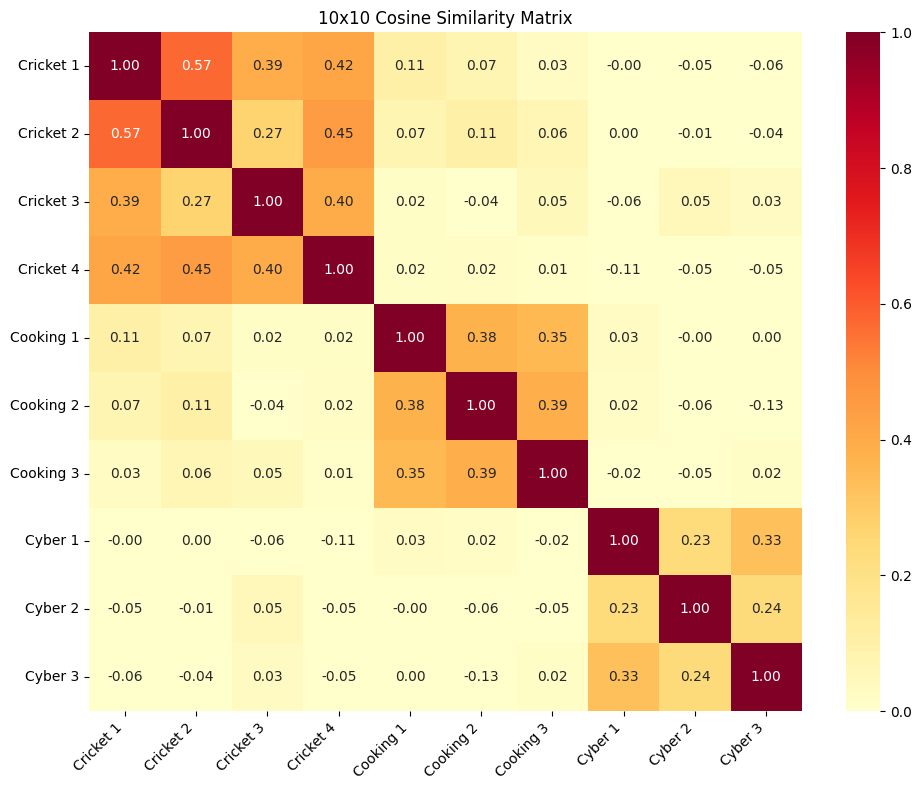

Heatmap saved!


In [4]:
# Cosine similarity matrix + heatmap
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Compute 10x10 similarity matrix
similarity_matrix = cosine_similarity(embeddings)

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt=".2f",
    xticklabels=labels,
    yticklabels=labels,
    cmap="YlOrRd",
    vmin=0,
    vmax=1
)
plt.title("10x10 Cosine Similarity Matrix")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig("similarity_heatmap.png", dpi=150)
plt.show()
print("Heatmap saved!")

In [5]:
# Find top 2 similar sentences for query
query = "The bowler took three wickets in one over"

# Generate embedding for query
query_embedding = model.encode([query])

# Compute similarity with all 10 sentences
query_similarities = cosine_similarity(query_embedding, embeddings)[0]

# Get top 2 matches
top_indices = query_similarities.argsort()[::-1][:2]

print(f"Query: '{query}'")
print(f"\nTop 2 most similar sentences:\n")
for rank, idx in enumerate(top_indices, 1):
    print(f"Rank {rank}:")
    print(f"  Sentence : {sentences[idx]}")
    print(f"  Label    : {labels[idx]}")
    print(f"  Similarity: {query_similarities[idx]:.4f}")

Query: 'The bowler took three wickets in one over'

Top 2 most similar sentences:

Rank 1:
  Sentence : The spinner took three wickets in one over with brilliant bowling
  Label    : Cricket 2
  Similarity: 0.8499
Rank 2:
  Sentence : The batsman played a beautiful cover drive off the fast bowler
  Label    : Cricket 1
  Similarity: 0.5898


In [6]:
# Summary
print("=" * 55)
print("EMBEDDINGS DEMO — SUMMARY")
print("=" * 55)
print(f"\nModel Used    : all-MiniLM-L6-v2")
print(f"Total Sentences: {len(sentences)}")
print(f"Topics         : Cricket, Cooking, Cybersecurity")
print(f"Embedding Size : {embeddings.shape[1]} dimensions")
print(f"\nQuery Sentence:")
print(f"  '{query}'")
print(f"\nTop 2 Similar Sentences:")
for rank, idx in enumerate(top_indices, 1):
    print(f"  Rank {rank}: {sentences[idx]}")
    print(f"          Similarity = {query_similarities[idx]:.4f}")
print("\nConclusion:")
print("  Same-topic sentences show high similarity (0.5-1.0)")
print("  Cross-topic sentences show low similarity (0.0-0.2)")
print("=" * 55)

EMBEDDINGS DEMO — SUMMARY

Model Used    : all-MiniLM-L6-v2
Total Sentences: 10
Topics         : Cricket, Cooking, Cybersecurity
Embedding Size : 384 dimensions

Query Sentence:
  'The bowler took three wickets in one over'

Top 2 Similar Sentences:
  Rank 1: The spinner took three wickets in one over with brilliant bowling
          Similarity = 0.8499
  Rank 2: The batsman played a beautiful cover drive off the fast bowler
          Similarity = 0.5898

Conclusion:
  Same-topic sentences show high similarity (0.5-1.0)
  Cross-topic sentences show low similarity (0.0-0.2)
